03_RISK_CLASSIFICATION.ipynb

1. Project Introduction
2. Import Libraries
3. Load Preprocessed Dataset
4. Define Features (X) and Target (y)
5. Train-Test Split
6. Feature Scaling
7. Decision Tree       ← Anshad
8. KNN                 ← Aswin
9. Random Forest       ← Pranav
10. Naive Bayes        ← Sreejeev
11. Model Evaluation
12. Comparison of 4 Models
13. Confusion Matrices
14. Final Results / Conclusion

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# GeoSafe — Risk Classification

### Machine Learning-Based Women's Safety Risk Classification

This notebook implements and evaluates four machine learning classification
algorithms for women's safety risk classification:

1. Decision Tree
2. K-Nearest Neighbors (KNN)
3. Random Forest
4. Naive Bayes

The models are evaluated using Accuracy, Precision, Recall, F1-score,
and Confusion Matrix.

Step 1 — Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


Step 2 — Load the preprocessed dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Women_Safety/Woman_Safety_Dataset_Cleaned.csv")

print("Preprocessed dataset loaded successfully.")
print("Shape:", df.shape)

Preprocessed dataset loaded successfully.
Shape: (20000, 20)


Step 3 — Inspect the dataset

In [ ]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (20000, 20)

Column names:
['incident_id', 'city', 'area', 'latitude', 'longitude', 'crime_type', 'crime_count', 'time_of_day', 'lighting_score', 'police_station_distance_km', 'crowd_density', 'weather_condition', 'safety_score', 'risk_level', 'incident_timestamp', 'incident_year', 'incident_month', 'incident_day', 'incident_hour', 'incident_dayofweek']

First 5 rows:


,incident_id,city,area,latitude,longitude,crime_type,crime_count,time_of_day,lighting_score,police_station_distance_km,crowd_density,weather_condition,safety_score,risk_level,incident_timestamp,incident_year,incident_month,incident_day,incident_hour,incident_dayofweek
0,2b63f176-a5c9-4ac5-adbb-b81c14754ec4,Kolkata,Park Street,22.587501,88.359752,Domestic Violence,23,Afternoon,2.26,1.00,768,Stormy,0.85,Low,2025-05-14 12:40:25,2025,5,14,12,2
1,ef4ba791-e5b5-4146-a3bb-c63e5d695e7c,Kolkata,Garia,22.565575,88.356876,Assault,4,Morning,1.84,2.01,626,Clear,0.92,Low,2024-11-02 08:14:54,2024,11,2,8,5
2,6db79d9c-62d4-4c74-a2f2-295297dbc083,Bhopal,Kolar,23.242474,77.396845,Verbal Abuse,25,Afternoon,5.04,2.37,900,Clear,0.89,Low,2026-01-27 03:45:27,2026,1,27,3,1
3,84fa6f88-339e-44b9-896a-6a548b8466c6,Mumbai,Kurla,18.997624,72.906211,Chain Snatching,19,Afternoon,2.94,6.16,114,Clear,0.58,Medium,2026-02-09 17:34:04,2026,2,9,17,0
4,9e5035a9-0d9b-40fc-a1e8-21702c65096e,Jaipur,Malviya Nagar,26.899559,75.765028,Chain Snatching,56,Evening,6.43,6.50,757,Humid,0.42,High,2025-02-16 06:47:57,2025,2,16,6,6


In [ ]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
incident_id                   0
city                          0
area                          0
latitude                      0
longitude                     0
crime_type                    0
crime_count                   0
time_of_day                   0
lighting_score                0
police_station_distance_km    0
crowd_density                 0
weather_condition             0
safety_score                  0
risk_level                    0
incident_timestamp            0
incident_year                 0
incident_month                0
incident_day                  0
incident_hour                 0
incident_dayofweek            0
dtype: int64


In [ ]:
print("\nData types:")
print(df.dtypes)


Data types:
incident_id                    object
city                           object
area                           object
latitude                      float64
longitude                     float64
crime_type                     object
crime_count                     int64
time_of_day                    object
lighting_score                float64
police_station_distance_km    float64
crowd_density                   int64
weather_condition              object
safety_score                  float64
risk_level                     object
incident_timestamp             object
incident_year                   int64
incident_month                  int64
incident_day                    int64
incident_hour                   int64
incident_dayofweek              int64
dtype: object


Step 4 — Identify the target column

In [ ]:
# ============================================
# IDENTIFY TARGET COLUMN
# ============================================

target_column = "risk_level"

print("Target column:", target_column)

Target column: risk_level


In [ ]:
# ============================================
# DEFINE FEATURES AND TARGET
# ============================================

# Remove target, identifiers, timestamp and
# target-derived safety_score

drop_columns = [
    "risk_level",
    "incident_id",
    "incident_timestamp",
    "safety_score"
]

X = df.drop(columns=drop_columns, errors="ignore")

y = df[target_column]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures used for classification:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.value_counts())

Features shape: (20000, 16)
Target shape: (20000,)

Features used for classification:
['city', 'area', 'latitude', 'longitude', 'crime_type', 'crime_count', 'time_of_day', 'lighting_score', 'police_station_distance_km', 'crowd_density', 'weather_condition', 'incident_year', 'incident_month', 'incident_day', 'incident_hour', 'incident_dayofweek']

Target classes:
risk_level
Low         9301
Medium      6940
High        3260
Critical     499
Name: count, dtype: int64


Step 5 — Check the target distribution

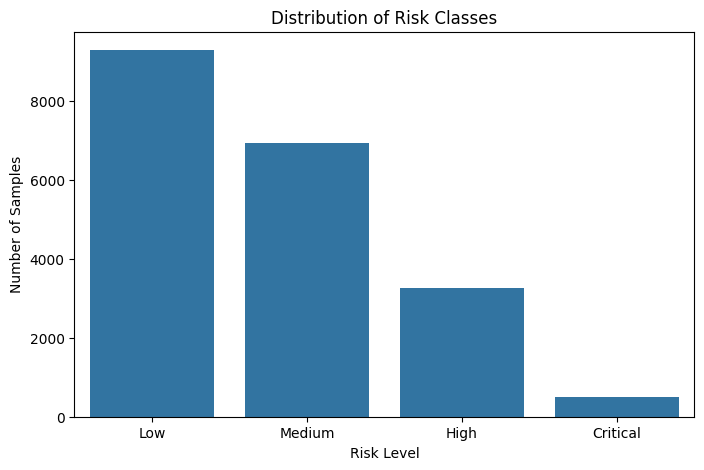

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(x=y)

plt.title("Distribution of Risk Classes")
plt.xlabel("Risk Level")
plt.ylabel("Number of Samples")
plt.show()

Step 6 — Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 16000
Testing samples : 4000


Step 7 — Feature Preprocessing

In [ ]:
# ============================================
# IDENTIFY FEATURE TYPES
# ============================================

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nSafety score included:",
      "safety_score" in X.columns)

Categorical features:
['city', 'area', 'crime_type', 'time_of_day', 'weather_condition']

Numerical features:
['latitude', 'longitude', 'crime_count', 'lighting_score', 'police_station_distance_km', 'crowd_density', 'incident_year', 'incident_month', 'incident_day', 'incident_hour', 'incident_dayofweek']

Safety score included: False


Step 8 — Create the preprocessing pipeline

In [ ]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [ ]:
print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['latitude', 'longitude', 'crime_count', 'lighting_score', 'police_station_distance_km', 'crowd_density', 'incident_year', 'incident_month', 'incident_day', 'incident_hour', 'incident_dayofweek']

Categorical features:
['city', 'area', 'crime_type', 'time_of_day', 'weather_condition']


Step 9 — Process training and testing data

In [ ]:
# Fit preprocessing only on training data
# Then transform both training and testing data

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully.")

print("Original X_train shape:", X_train.shape)
print("Original X_test shape :", X_test.shape)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape :", X_test_processed.shape)

Preprocessing completed successfully.
Original X_train shape: (16000, 16)
Original X_test shape : (4000, 16)
Processed X_train shape: (16000, 91)
Processed X_test shape : (4000, 91)


Step 10 — Add a verification cell

In [ ]:
print("===== CLASSIFICATION DATA PREPARATION COMPLETE =====")

print("X_train_processed:", X_train_processed.shape)
print("X_test_processed :", X_test_processed.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

===== CLASSIFICATION DATA PREPARATION COMPLETE =====
X_train_processed: (16000, 91)
X_test_processed : (4000, 91)
y_train: (16000,)
y_test : (4000,)

Training class distribution:
risk_level
Low         7441
Medium      5552
High        2608
Critical     399
Name: count, dtype: int64

Testing class distribution:
risk_level
Low         1860
Medium      1388
High         652
Critical     100
Name: count, dtype: int64


# Step 11 — Decision Tree Classification
### Implemented by: Anshad

Decision Tree trained successfully.

DECISION TREE RESULTS
Accuracy : 0.8043
Precision: 0.8031
Recall   : 0.8043
F1-Score : 0.8022

Classification Report:
              precision    recall  f1-score   support

    Critical       0.71      0.56      0.63       100
        High       0.75      0.62      0.68       652
         Low       0.88      0.90      0.89      1860
      Medium       0.73      0.78      0.75      1388

    accuracy                           0.80      4000
   macro avg       0.77      0.71      0.74      4000
weighted avg       0.80      0.80      0.80      4000



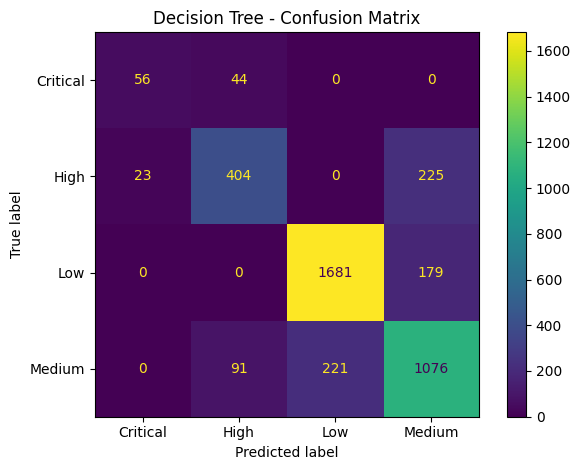


Decision Tree results stored successfully.
{'Model': 'Decision Tree', 'Accuracy': 0.80425, 'Precision': 0.8031443259430013, 'Recall': 0.80425, 'F1-Score': 0.8021543656641776}


In [ ]:
 # ============================================
# DECISION TREE CLASSIFIER
# ============================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# --------------------------------------------
# 1. Create Decision Tree model
# --------------------------------------------

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# --------------------------------------------
# 2. Train the model
# --------------------------------------------

dt_model.fit(X_train_processed, y_train)

print("Decision Tree trained successfully.")

# --------------------------------------------
# 3. Make predictions
# --------------------------------------------

y_pred_dt = dt_model.predict(X_test_processed)

# --------------------------------------------
# 4. Calculate evaluation metrics
# --------------------------------------------

dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_precision = precision_score(
    y_test,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

dt_recall = recall_score(
    y_test,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

# --------------------------------------------
# 5. Display results
# --------------------------------------------

print("\n================================")
print("DECISION TREE RESULTS")
print("================================")

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-Score : {dt_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_dt,
    zero_division=0
))

# --------------------------------------------
# 6. Confusion Matrix
# --------------------------------------------

cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=dt_model.classes_
)

disp.plot(values_format="d")

plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 7. Store results
# --------------------------------------------

dt_results = {
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "F1-Score": dt_f1
}

print("\nDecision Tree results stored successfully.")
print(dt_results)

# Step 12 — Naive Bayes Classification
### Implemented by: Sreejeev

In [ ]:
# ============================================
# NAIVE BAYES CLASSIFIER
# ============================================

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# --------------------------------------------
# 1. Convert sparse matrix to dense if needed
# --------------------------------------------

if hasattr(X_train_processed, "toarray"):
    X_train_nb = X_train_processed.toarray()
    X_test_nb = X_test_processed.toarray()
else:
    X_train_nb = X_train_processed
    X_test_nb = X_test_processed

# --------------------------------------------
# 2. Create Naive Bayes model
# --------------------------------------------

nb_model = GaussianNB()

# --------------------------------------------
# 3. Train the model
# --------------------------------------------

nb_model.fit(X_train_nb, y_train)

# --------------------------------------------
# 4. Make predictions
# --------------------------------------------

y_pred_nb = nb_model.predict(X_test_nb)

# --------------------------------------------
# 5. Calculate evaluation metrics
# --------------------------------------------

nb_accuracy = accuracy_score(y_test, y_pred_nb)

nb_precision = precision_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)

nb_recall = recall_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)

nb_f1 = f1_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)

# --------------------------------------------
# 6. Display results
# --------------------------------------------

print("===== NAIVE BAYES RESULTS =====")

print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1-Score : {nb_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_nb,
    zero_division=0
))

===== NAIVE BAYES RESULTS =====
Accuracy : 0.5075
Precision: 0.5381
Recall   : 0.5075
F1-Score : 0.5181

Classification Report:
              precision    recall  f1-score   support

    Critical       0.24      0.59      0.34       100
        High       0.32      0.34      0.33       652
         Low       0.72      0.60      0.65      1860
      Medium       0.42      0.46      0.44      1388

    accuracy                           0.51      4000
   macro avg       0.42      0.50      0.44      4000
weighted avg       0.54      0.51      0.52      4000



Step 12 — Naive Bayes Confusion Matrix

<Figure size 700x500 with 0 Axes>

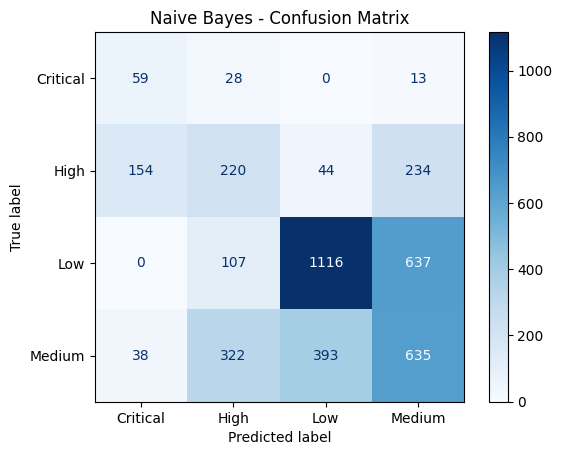

In [ ]:
# ============================================
# NAIVE BAYES CONFUSION MATRIX
# ============================================

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=nb_model.classes_
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Naive Bayes - Confusion Matrix")
plt.show()

In [ ]:
# ============================================
# STORE NAIVE BAYES RESULTS
# ============================================

nb_results = {
    "Model": "Naive Bayes",
    "Accuracy": nb_accuracy,
    "Precision": nb_precision,
    "Recall": nb_recall,
    "F1-Score": nb_f1
}

print("Naive Bayes results stored successfully.")
print(nb_results)

Naive Bayes results stored successfully.
{'Model': 'Naive Bayes', 'Accuracy': 0.5075, 'Precision': 0.5380579760985614, 'Recall': 0.5075, 'F1-Score': 0.518062196279858}


# Step 13 — K-Nearest Neighbors (KNN)
### Implemented by: Aswin

In [ ]:
# ============================================
# K-NEAREST NEIGHBORS (KNN) CLASSIFIER
# ============================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# --------------------------------------------
# 1. Create KNN model
# --------------------------------------------

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# --------------------------------------------
# 2. Train the model
# --------------------------------------------

knn_model.fit(X_train_processed, y_train)

# --------------------------------------------
# 3. Make predictions
# --------------------------------------------

y_pred_knn = knn_model.predict(X_test_processed)

# --------------------------------------------
# 4. Calculate evaluation metrics
# --------------------------------------------

knn_accuracy = accuracy_score(y_test, y_pred_knn)

knn_precision = precision_score(
    y_test,
    y_pred_knn,
    average="weighted",
    zero_division=0
)

knn_recall = recall_score(
    y_test,
    y_pred_knn,
    average="weighted",
    zero_division=0
)

knn_f1 = f1_score(
    y_test,
    y_pred_knn,
    average="weighted",
    zero_division=0
)

# --------------------------------------------
# 5. Display results
# --------------------------------------------

print("===== KNN RESULTS =====")

print(f"Accuracy : {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall   : {knn_recall:.4f}")
print(f"F1-Score : {knn_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_knn,
    zero_division=0
))

===== KNN RESULTS =====
Accuracy : 0.6963
Precision: 0.6887
Recall   : 0.6963
F1-Score : 0.6899

Classification Report:
              precision    recall  f1-score   support

    Critical       0.55      0.21      0.30       100
        High       0.57      0.55      0.56       652
         Low       0.80      0.86      0.83      1860
      Medium       0.61      0.59      0.60      1388

    accuracy                           0.70      4000
   macro avg       0.63      0.55      0.57      4000
weighted avg       0.69      0.70      0.69      4000



Step 14 — KNN Confusion Matrix

<Figure size 700x500 with 0 Axes>

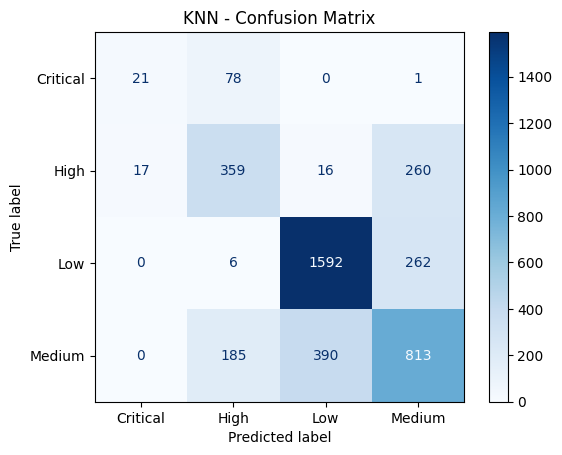

In [ ]:
# ============================================
# KNN CONFUSION MATRIX
# ============================================

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=knn_model.classes_
)

disp.plot(cmap="Blues", values_format="d")

plt.title("KNN - Confusion Matrix")
plt.show()

In [ ]:
# ============================================
# STORE KNN RESULTS
# ============================================

knn_results = {
    "Model": "KNN",
    "Accuracy": knn_accuracy,
    "Precision": knn_precision,
    "Recall": knn_recall,
    "F1-Score": knn_f1
}

print("KNN results stored successfully.")
print(knn_results)

KNN results stored successfully.
{'Model': 'KNN', 'Accuracy': 0.69625, 'Precision': 0.6886671644336397, 'Recall': 0.69625, 'F1-Score': 0.6899350721864022}


# Step 18 — Random Forest Classification
### Implemented by: Pranav

Random Forest trained successfully.

       RANDOM FOREST RESULTS
Accuracy : 0.8888 (88.88%)
Precision: 0.8909 (89.09%)
Recall   : 0.8888 (88.88%)
F1-Score : 0.8848 (88.48%)

Classification Report:
              precision    recall  f1-score   support

    Critical       1.00      0.36      0.53       100
        High       0.87      0.75      0.80       652
         Low       0.93      0.96      0.94      1860
      Medium       0.84      0.90      0.87      1388

    accuracy                           0.89      4000
   macro avg       0.91      0.74      0.79      4000
weighted avg       0.89      0.89      0.88      4000


Confusion Matrix:
[[  36   64    0    0]
 [   0  487    0  165]
 [   0    0 1783   77]
 [   0    7  132 1249]]


<Figure size 800x600 with 0 Axes>

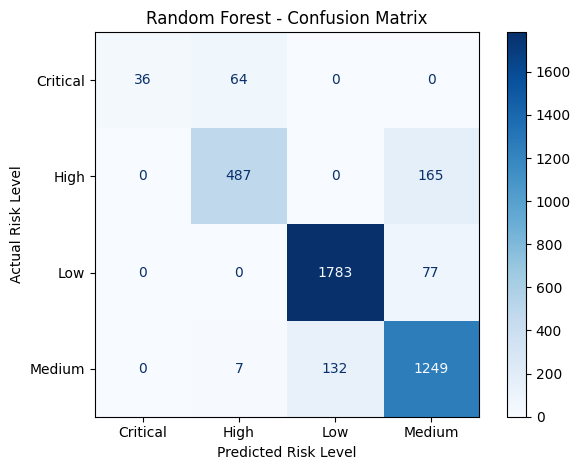


Random Forest results stored successfully.
{'Model': 'Random Forest', 'Accuracy': 0.88875, 'Precision': 0.8908870471017614, 'Recall': 0.88875, 'F1-Score': 0.884778034541343}


In [ ]:
# ============================================
# RANDOM FOREST CLASSIFIER
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# --------------------------------------------
# 1. Create Random Forest model
# --------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

# --------------------------------------------
# 2. Train the model
# --------------------------------------------

rf_model.fit(X_train_processed, y_train)

print("Random Forest trained successfully.")

# --------------------------------------------
# 3. Make predictions
# --------------------------------------------

y_pred_rf = rf_model.predict(X_test_processed)

# --------------------------------------------
# 4. Calculate evaluation metrics
# --------------------------------------------

rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

# --------------------------------------------
# 5. Display performance
# --------------------------------------------

print("\n==========================================")
print("       RANDOM FOREST RESULTS")
print("==========================================")

print(f"Accuracy : {rf_accuracy:.4f} ({rf_accuracy * 100:.2f}%)")
print(f"Precision: {rf_precision:.4f} ({rf_precision * 100:.2f}%)")
print(f"Recall   : {rf_recall:.4f} ({rf_recall * 100:.2f}%)")
print(f"F1-Score : {rf_f1:.4f} ({rf_f1 * 100:.2f}%)")

# --------------------------------------------
# 6. Classification report
# --------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

# --------------------------------------------
# 7. Confusion Matrix
# --------------------------------------------

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=rf_model.classes_
)

print("\nConfusion Matrix:")
print(cm_rf)

# --------------------------------------------
# 8. Plot Confusion Matrix
# --------------------------------------------

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=rf_model.classes_
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Risk Level")
plt.ylabel("Actual Risk Level")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 9. Store results
# --------------------------------------------

rf_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1-Score": rf_f1
}

print("\nRandom Forest results stored successfully.")
print(rf_results)

In [ ]:
# ============================================
# MODEL COMPARISON
# ============================================

comparison = pd.DataFrame([
    dt_results,
    nb_results,
    knn_results,
    rf_results
])

print("===== MODEL COMPARISON =====")
display(comparison)

===== MODEL COMPARISON =====


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.80425,0.803144,0.80425,0.802154
1,Naive Bayes,0.50750,0.538058,0.50750,0.518062
2,KNN,0.69625,0.688667,0.69625,0.689935
3,Random Forest,0.88875,0.890887,0.88875,0.884778


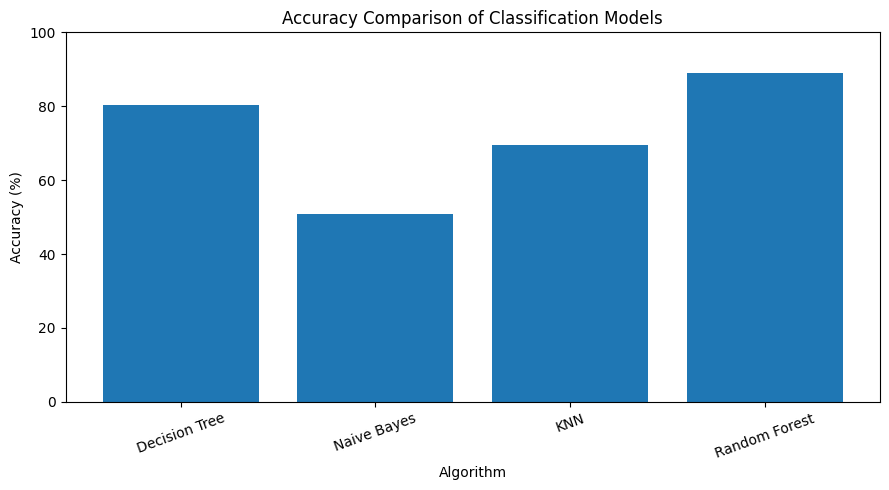

In [ ]:
# ============================================
# ACCURACY COMPARISON
# ============================================

plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"] * 100
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Algorithm")
plt.title("Accuracy Comparison of Classification Models")
plt.xticks(rotation=20)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FINAL MODEL COMPARISON FOR GEOSAFE WEBSITE
# ============================================================

comparison_final = comparison.copy()

comparison_final["Accuracy (%)"] = comparison_final["Accuracy"] * 100
comparison_final["Precision (%)"] = comparison_final["Precision"] * 100
comparison_final["Recall (%)"] = comparison_final["Recall"] * 100
comparison_final["F1-Score (%)"] = comparison_final["F1-Score"] * 100

comparison_final = comparison_final[
    [
        "Model",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1-Score (%)"
    ]
]

display(comparison_final)

,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,Decision Tree,80.425,80.314433,80.425,80.215437
1,Naive Bayes,50.750,53.805798,50.750,51.806220
2,KNN,69.625,68.866716,69.625,68.993507
3,Random Forest,88.875,89.088705,88.875,88.477803


In [ ]:
# ============================================================
# SAVE MODEL METRICS FOR WEBSITE
# ============================================================

OUTPUT_PATH = "/content/drive/MyDrive/Women_Safety/outputs"

comparison_final.to_csv(
    f"{OUTPUT_PATH}/geosafe_model_metrics.csv",
    index=False
)

print("Model metrics saved successfully.")

Model metrics saved successfully.


In [ ]:
# ============================================================
# SAVE TRAINED MODELS + PREPROCESSOR FOR GEOSAFE WEBSITE
# ============================================================

import os
import joblib

MODEL_DIR = "/content/drive/MyDrive/Women_Safety/outputs/models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Save the preprocessing object
joblib.dump(
    preprocessor,
    f"{MODEL_DIR}/preprocessor.pkl"
)

# Save the four trained classifiers
joblib.dump(
    dt_model,
    f"{MODEL_DIR}/decision_tree.pkl"
)

joblib.dump(
    nb_model,
    f"{MODEL_DIR}/naive_bayes.pkl"
)

joblib.dump(
    knn_model,
    f"{MODEL_DIR}/knn.pkl"
)

joblib.dump(
    rf_model,
    f"{MODEL_DIR}/random_forest.pkl"
)

print("All models and preprocessing object saved successfully.")

All models and preprocessing object saved successfully.


In [ ]:
# ============================================================
# VERIFY SAVED MODEL FILES
# ============================================================

import os

expected_files = [
    "preprocessor.pkl",
    "decision_tree.pkl",
    "naive_bayes.pkl",
    "knn.pkl",
    "random_forest.pkl"
]

print("Checking saved files...\n")

all_found = True

for filename in expected_files:
    path = os.path.join(MODEL_DIR, filename)

    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"✓ {filename} ({size_kb:.1f} KB)")
    else:
        print(f"✗ {filename} NOT FOUND")
        all_found = False

print()

if all_found:
    print("SUCCESS: All model files are ready for the website.")
else:
    print("Some files are missing. Check the output above.")

Checking saved files...

✓ preprocessor.pkl (5.0 KB)
✓ decision_tree.pkl (7.4 KB)
✓ naive_bayes.pkl (6.6 KB)
✓ knn.pkl (3188.7 KB)
✓ random_forest.pkl (70372.1 KB)

SUCCESS: All model files are ready for the website.


In [ ]:
import sklearn
print("Training scikit-learn version:", sklearn.__version__)

Training scikit-learn version: 1.6.1
